# Visium HD 多数据集 EDA

对比三个 Visium HD 数据集的数据分布，为新实验做准备。

| 数据集 | 组织类型 | 细胞数 | 基因数 |
|---|---|---|---|
| human_crc | 结直肠癌 | 185,555 | 2,250 |
| human_lungcancer | 肺癌 | 119,078 | 1,226 |
| human_pancreas | 胰腺 | 22,975 | 508 |

**章节：**
1. Setup & 加载数据
2. 基本统计对比
3. 空间分布
4. 表达矩阵分布
5. 基因覆盖率分布
6. 基因重叠分析
7. 细胞形态分布

## 1. Setup & 加载数据

In [4]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import gc

VISIUM_ROOT = Path('/hpc/group/jilab/boxuan/visiumHD')
MORPH_ROOT  = Path('/hpc/group/jilab/hz/MorphPT/data/visiumHD')

#DATASETS = ['human_crc', 'human_lungcancer', 'human_pancreas']
DATASETS = ['human_crc']
COLORS   = {'human_crc': '#C44E52', 'human_lungcancer': '#4C72B0', 'human_pancreas': '#55A868'}
LABELS   = {'human_crc': 'CRC', 'human_lungcancer': 'Lung Cancer', 'human_pancreas': 'Pancreas'}

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False
})
print('Setup done.')

Setup done.


In [5]:
stats = {}

for name in DATASETS:
    print(f'Processing {name}...')
    root = VISIUM_ROOT / name

    # Load sparse (NOT dense)
    X     = sio.mmread(root / 'expr/expr.mtx').tocsr()
    genes = (root / 'expr/genes.txt').read_text().splitlines()
    cells = (root / 'expr/cells.txt').read_text().splitlines()

    if X.shape[0] == len(genes):
        X = X.T.tocsr()

    n_cells, n_genes = X.shape

    s = {
        'n_cells':     n_cells,
        'n_genes':     n_genes,
        'sparsity':    1 - X.nnz / (n_cells * n_genes),
        'genes':       genes,
        # Small arrays only
        'cell_total':  np.array(X.sum(axis=1), dtype=np.float32).ravel(),
        'cell_ngenes': np.diff(X.indptr).astype(np.int32),
        'gene_total':  np.array(X.sum(axis=0), dtype=np.float32).ravel(),
        'gene_ncells': np.array((X > 0).sum(axis=0), dtype=np.int32).ravel(),
        # Sample nz values instead of storing all
        'nz_sample':   np.random.choice(X.data, 
                           size=min(100000, len(X.data)), 
                           replace=False).astype(np.float32),
        'nz_min':      float(X.data.min()),
        'nz_max':      float(X.data.max()),
        'nz_mean':     float(X.data.mean()),
        'nz_is_int':   bool(np.all(X.data == X.data.astype(int))),
    }

    # Free immediately
    del X
    gc.collect()

    # Spatial (read only x, y columns — not full file)
    sp_path = MORPH_ROOT / name / 'spatial.csv'
    if sp_path.exists():
        s['spatial'] = pd.read_csv(sp_path, usecols=['cell_id', 'x_centroid', 'y_centroid'])
    else:
        s['spatial'] = None

    # Meta (read only morphology columns needed)
    meta_path = VISIUM_ROOT / name / f'meta/10.0x/{name}.csv'
    if meta_path.exists():
        keep_cols = ['cell_id', 'biological_area_um2', 'biological_diameter_um',
                     'aspect_ratio', 'coverage']
        available = pd.read_csv(meta_path, nrows=0).columns.tolist()
        use_cols  = [c for c in keep_cols if c in available]
        s['meta'] = pd.read_csv(meta_path, usecols=use_cols)
    else:
        s['meta'] = None

    stats[name] = s
    print(f'  {n_cells:,} cells × {n_genes:,} genes  '
          f'sparsity={s["sparsity"]:.1%}  '
          f'NZ range=[{s["nz_min"]:.2f}, {s["nz_max"]:.2f}]  '
          f'integers={s["nz_is_int"]}')
    print(f'  Done.')

print('\nAll datasets processed. Safe to plot.')

Processing human_crc...
  185,555 cells × 2,250 genes  sparsity=82.6%  NZ range=[0.92, 8.87]  integers=False
  Done.

All datasets processed. Safe to plot.


## 2. 基本统计对比

In [9]:
# Print summary table
print(f"{'Dataset':<20} {'Cells':>10} {'Genes':>8} {'Sparsity':>10} "
      f"{'Genes/cell':>12} {'NZ range':>20}")
print('-' * 85)
for name in DATASETS:
    d  = stats[name]
    print(f"{LABELS[name]:<20} {d['n_cells']:>10,} {d['n_genes']:>8,} "
          f"{d['sparsity']:>9.1%} {d['cell_ngenes'].mean():>12.1f} "
          f"  [{d['nz_min']:.2f}, {d['nz_max']:.2f}]")

Dataset                   Cells    Genes   Sparsity   Genes/cell             NZ range
-------------------------------------------------------------------------------------
CRC                     185,555    2,250     82.6%        391.0   [0.92, 8.87]


In [10]:
# Top 10 genes per dataset
for name in DATASETS:
    d = stats[name]
    top10 = np.argsort(d['gene_total'])[::-1][:10]
    print(f"\n{LABELS[name]} — Top 10 genes:")
    print(f"  {'Gene':<20} {'TotalCount':>12} {'Coverage':>10}")
    for i in top10:
        print(f"  {d['genes'][i]:<20} {int(d['gene_total'][i]):>12,} "
              f"{d['gene_ncells'][i]/d['n_cells']:>9.1%}")


CRC — Top 10 genes:
  Gene                   TotalCount   Coverage
  MT-ATP6                   823,378     96.7%
  MT-ND4                    823,325     96.7%
  TMSB4X                    761,481     97.0%
  MT-CO3                    755,878     95.0%
  MT-CO2                    652,755     89.6%
  MT-CYB                    632,184     89.5%
  FTH1                      578,018     84.3%
  ACTB                      526,609     83.2%
  MT-ND3                    515,589     80.4%
  CEACAM5                   511,296     74.2%


## 3. 空间分布

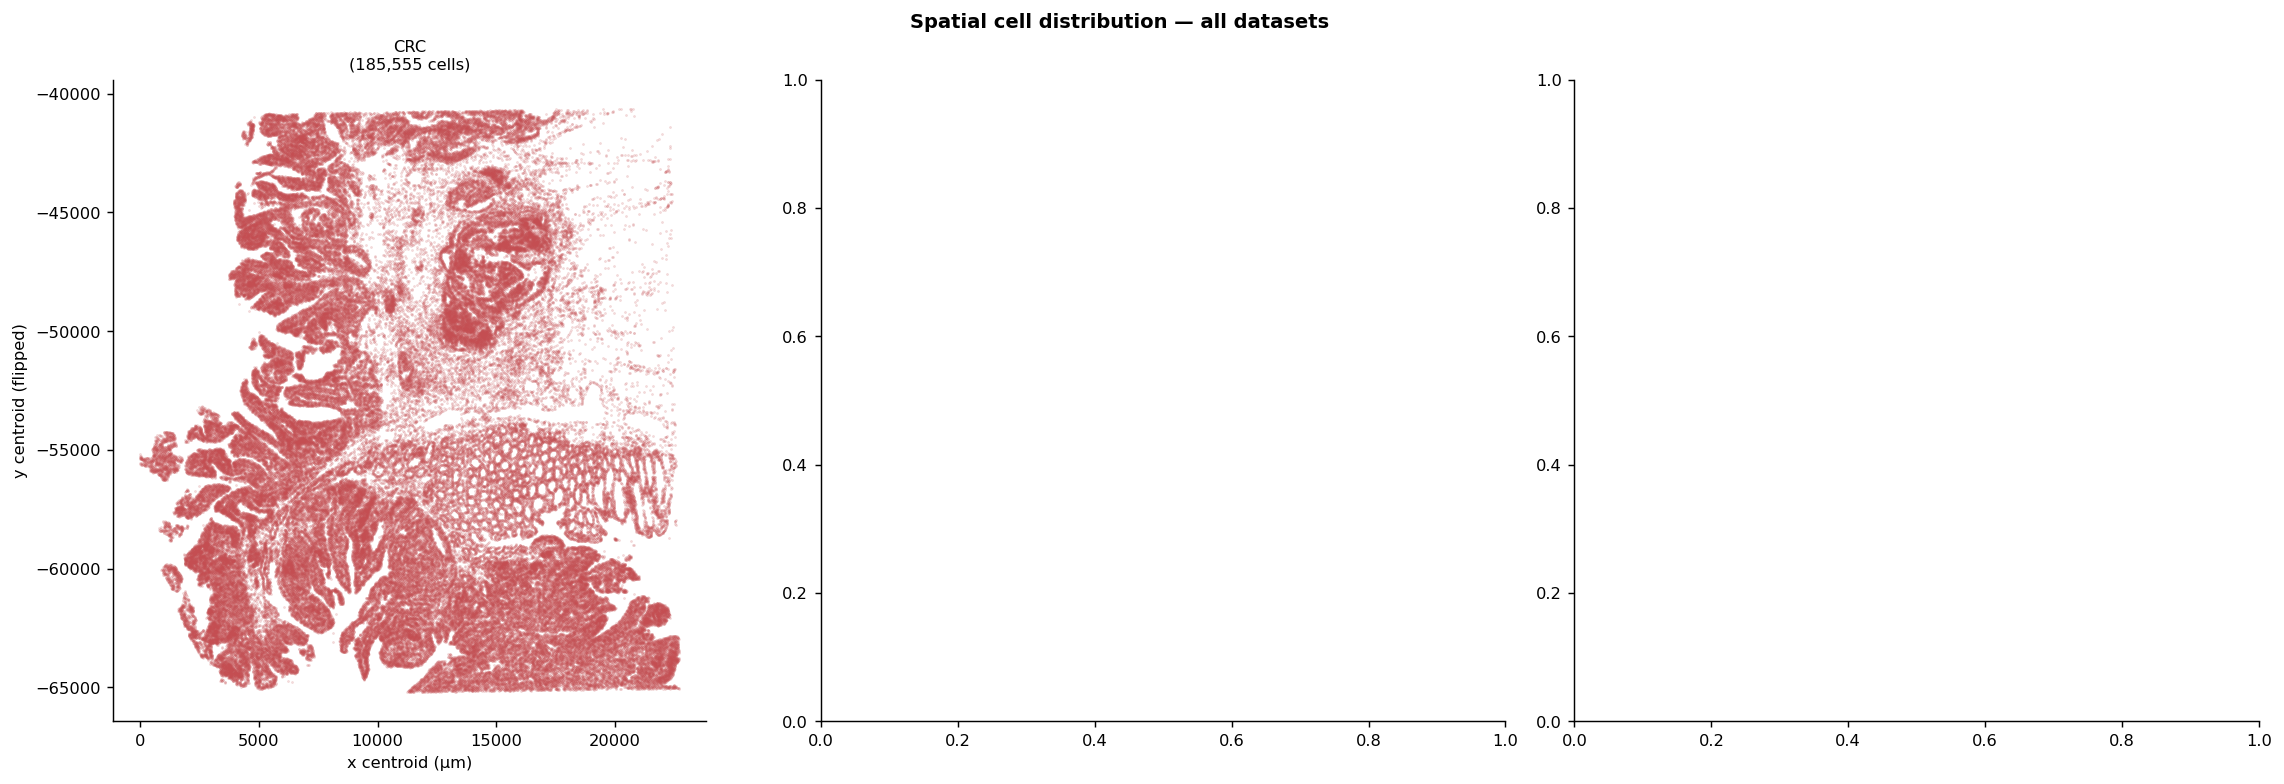

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, name in zip(axes, DATASETS):
    d  = stats[name]
    sp = d['spatial']
    if sp is not None:
        ax.scatter(sp['x_centroid'], -sp['y_centroid'],
                   s=0.2, alpha=0.25, color=COLORS[name], rasterized=True)
        ax.set_xlabel('x centroid (µm)')
        ax.set_ylabel('y centroid (flipped)')
        ax.set_aspect('equal')
    else:
        ax.text(0.5, 0.5, 'spatial.csv not found',
                ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f"{LABELS[name]}\n({d['n_cells']:,} cells)", fontsize=9)

fig.suptitle('Spatial cell distribution — all datasets', fontweight='bold')
fig.tight_layout()
plt.show()

## 4. 表达矩阵分布

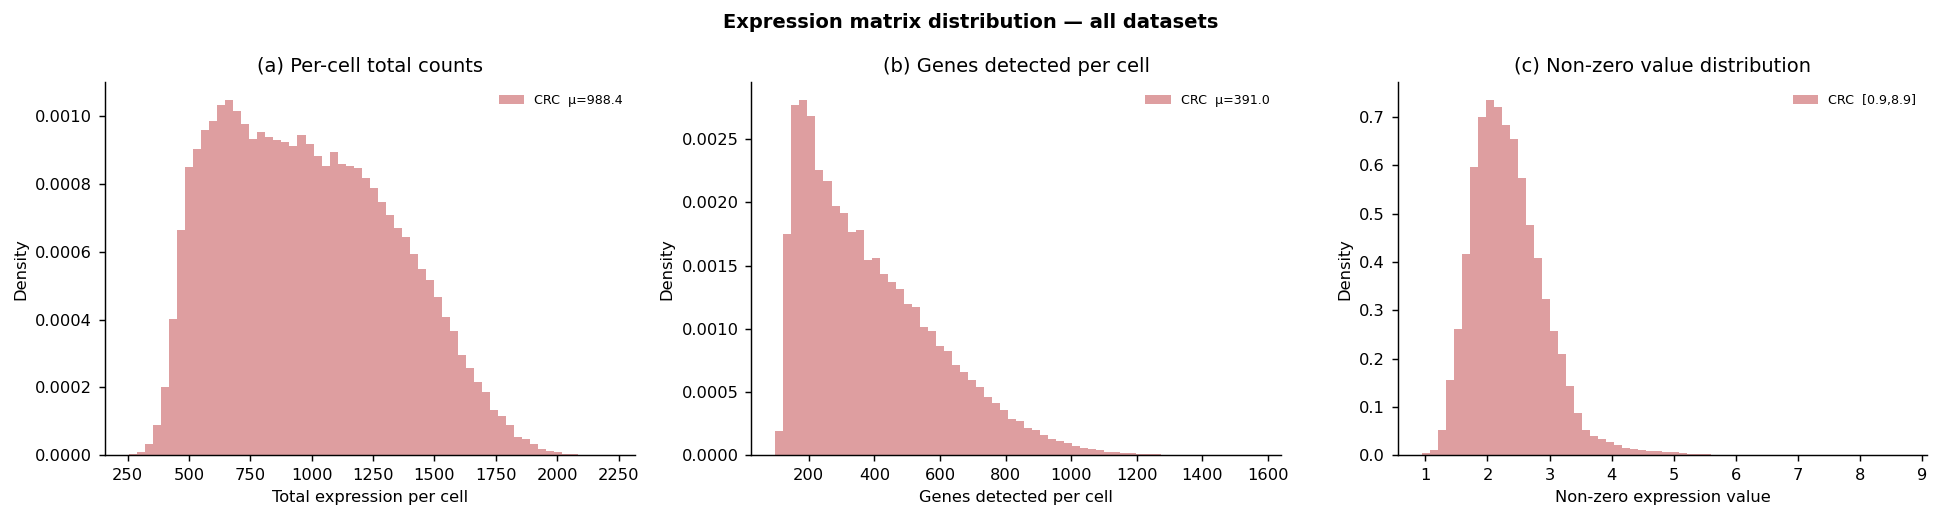

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Per-cell total counts
ax = axes[0]
for name in DATASETS:
    d = stats[name]
    ax.hist(d['cell_total'], bins=60, alpha=0.55,
            color=COLORS[name], density=True, edgecolor='none',
            label=f"{LABELS[name]}  μ={d['cell_total'].mean():.1f}")
ax.set_xlabel('Total expression per cell')
ax.set_ylabel('Density')
ax.set_title('(a) Per-cell total counts')
ax.legend(fontsize=7)

# Per-cell genes detected
ax = axes[1]
for name in DATASETS:
    d = stats[name]
    ax.hist(d['cell_ngenes'], bins=60, alpha=0.55,
            color=COLORS[name], density=True, edgecolor='none',
            label=f"{LABELS[name]}  μ={d['cell_ngenes'].mean():.1f}")
ax.set_xlabel('Genes detected per cell')
ax.set_ylabel('Density')
ax.set_title('(b) Genes detected per cell')
ax.legend(fontsize=7)

PROJECT_ROOT = Path('/hpc/group/jilab/tc459/MorphPT')
# Non-zero value distribution
ax = axes[2]
for name in DATASETS:
    d  = stats[name]
    clean_name = name.replace('human_', '')
    expr_path = PROJECT_ROOT / f'cache_{clean_name}' / 'expr.npy'
    if expr_path.exists():
        # 用 mmap_mode='r' 闪电加载，不占内存
        expr = np.load(str(expr_path), mmap_mode='r')
        
        # 只取前 5000 个细胞的所有基因作为采样，并展平
        sample_batch = expr[:5000].astype(np.float32).flatten()
        # 过滤出非零值
        nz = sample_batch[sample_batch > 0]
        
        ax.hist(nz, bins=60, alpha=0.55,
                color=COLORS[name], density=True, edgecolor='none',
                label=f"{LABELS[name]}  [{d['nz_min']:.1f},{d['nz_max']:.1f}]")
    else:
        print(f"Warning: Could not find {expr_path}")
ax.set_xlabel('Non-zero expression value')
ax.set_ylabel('Density')
ax.set_title('(c) Non-zero value distribution')
ax.legend(fontsize=7)

fig.suptitle('Expression matrix distribution — all datasets', fontweight='bold')
fig.tight_layout()
plt.show()

## 5. 基因覆盖率分布

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Coverage histogram
ax = axes[0]
for name in DATASETS:
    d        = data[name]
    coverage = d['gene_ncells'] / d['n_cells'] * 100
    ax.hist(coverage, bins=50, alpha=0.55,
            color=COLORS[name], density=True, edgecolor='none',
            label=f"{LABELS[name]}  μ={coverage.mean():.1f}%")
ax.set_xlabel('% cells expressing gene')
ax.set_ylabel('Density')
ax.set_title('(a) Gene expression prevalence')
ax.legend(fontsize=7)

# Coverage bins comparison
ax    = axes[1]
bins  = [0, 10, 20, 30, 50, 100]
blabels = ['<10%', '10-20%', '20-30%', '30-50%', '>50%']
x     = np.arange(len(blabels))
width = 0.25

for i, name in enumerate(DATASETS):
    d        = data[name]
    coverage = d['gene_ncells'] / d['n_cells'] * 100
    counts   = [((coverage >= bins[j]) & (coverage < bins[j+1])).sum()
                for j in range(len(blabels))]
    offset   = (i - 1) * width
    bars = ax.bar(x + offset, counts, width=width*0.9,
                  color=COLORS[name], alpha=0.85, label=LABELS[name])
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1, str(cnt),
                    ha='center', va='bottom', fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(blabels, fontsize=8)
ax.set_ylabel('Number of genes')
ax.set_title('(b) Genes per coverage bin')
ax.legend(fontsize=7)

fig.suptitle('Per-gene coverage distribution — all datasets', fontweight='bold')
fig.tight_layout()
plt.show()

## 6. 基因重叠分析

In [ ]:
gene_sets = {name: set(data[name]['genes']) for name in DATASETS}

# Print overlap stats
print('Gene panel sizes:')
for name in DATASETS:
    print(f'  {LABELS[name]:<15}: {len(gene_sets[name]):,} genes')

print('\nPairwise overlaps:')
names = DATASETS
for i in range(len(names)):
    for j in range(i+1, len(names)):
        overlap = gene_sets[names[i]] & gene_sets[names[j]]
        pct_i   = len(overlap) / len(gene_sets[names[i]]) * 100
        pct_j   = len(overlap) / len(gene_sets[names[j]]) * 100
        print(f'  {LABELS[names[i]]} ∩ {LABELS[names[j]]}: '
              f'{len(overlap):,} genes  '
              f'({pct_i:.0f}% of {LABELS[names[i]]}, {pct_j:.0f}% of {LABELS[names[j]]})')

all_three = gene_sets[names[0]] & gene_sets[names[1]] & gene_sets[names[2]]
print(f'\nAll three datasets: {len(all_three):,} shared genes')

In [ ]:
# Overlap matrix heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overlap matrix
ax = axes[0]
n  = len(DATASETS)
mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        mat[i, j] = len(gene_sets[DATASETS[i]] & gene_sets[DATASETS[j]])

im = ax.imshow(mat, cmap='Blues')
plt.colorbar(im, ax=ax, label='# shared genes')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([LABELS[n] for n in DATASETS], fontsize=8)
ax.set_yticklabels([LABELS[n] for n in DATASETS], fontsize=8)
ax.set_title('(a) Gene overlap matrix', fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{int(mat[i,j]):,}', ha='center', va='center',
                fontsize=9, color='white' if mat[i,j] > mat.max()*0.6 else 'black')

# Right: bar chart of gene counts
ax = axes[1]
bar_data = [
    ('Only CRC',   len(gene_sets['human_crc'] - gene_sets['human_lungcancer'] - gene_sets['human_pancreas']),   '#C44E52'),
    ('Only Lung',  len(gene_sets['human_lungcancer'] - gene_sets['human_crc'] - gene_sets['human_pancreas']),   '#4C72B0'),
    ('Only Panc',  len(gene_sets['human_pancreas'] - gene_sets['human_crc'] - gene_sets['human_lungcancer']),   '#55A868'),
    ('CRC+Lung',   len((gene_sets['human_crc'] & gene_sets['human_lungcancer']) - gene_sets['human_pancreas']), '#9B5EA2'),
    ('CRC+Panc',   len((gene_sets['human_crc'] & gene_sets['human_pancreas']) - gene_sets['human_lungcancer']), '#E08F3A'),
    ('Lung+Panc',  len((gene_sets['human_lungcancer'] & gene_sets['human_pancreas']) - gene_sets['human_crc']), '#2E9E7A'),
    ('All three',  len(all_three),  '#555555'),
]
labels_b = [b[0] for b in bar_data]
values_b = [b[1] for b in bar_data]
colors_b = [b[2] for b in bar_data]
bars = ax.bar(range(len(bar_data)), values_b, color=colors_b, alpha=0.85)
for bar, val in zip(bars, values_b):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, str(val),
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(bar_data)))
ax.set_xticklabels(labels_b, fontsize=7, rotation=30)
ax.set_ylabel('Number of genes')
ax.set_title('(b) Gene membership breakdown', fontsize=9)

fig.suptitle('Gene panel overlap across datasets', fontweight='bold')
fig.tight_layout()
plt.show()

# Print shared genes
print(f'\nTop 15 shared genes (all three datasets), sorted by CRC coverage:')
crc = data['human_crc']
shared_sorted = sorted(
    all_three,
    key=lambda g: crc['gene_ncells'][crc['genes'].index(g)] / crc['n_cells']
    if g in crc['genes'] else 0,
    reverse=True
)
print(f"  {'Gene':<20} {'CRC cov':>10} {'Lung cov':>10} {'Panc cov':>10}")
for g in shared_sorted[:15]:
    covs = {}
    for dname in DATASETS:
        d = data[dname]
        if g in d['genes']:
            idx = d['genes'].index(g)
            covs[dname] = d['gene_ncells'][idx] / d['n_cells']
        else:
            covs[dname] = 0.0
    print(f"  {g:<20} {covs['human_crc']:>9.1%} "
          f"{covs['human_lungcancer']:>10.1%} "
          f"{covs['human_pancreas']:>10.1%}")

## 7. 细胞形态分布

In [ ]:
morph_cols   = ['biological_area_um2', 'biological_diameter_um', 'aspect_ratio', 'coverage']
morph_labels = ['Nuclear area (µm²)', 'Nuclear diameter (µm)', 'Aspect ratio', 'Coverage']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for i, (col, label) in enumerate(zip(morph_cols, morph_labels)):
    ax = axes[i]
    for name in DATASETS:
        meta = data[name]['meta']
        if meta is None or col not in meta.columns:
            continue
        vals = meta[col].dropna()
        ax.hist(vals, bins=60, alpha=0.55,
                color=COLORS[name], density=True, edgecolor='none',
                label=f"{LABELS[name]}  μ={vals.mean():.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'({chr(97+i)}) {label}')
    ax.legend(fontsize=7)

fig.suptitle('Cell morphology distribution — all datasets', fontweight='bold')
fig.tight_layout()
plt.show()

# Summary stats
print('\nMorphology summary (mean ± std):')
for col, label in zip(morph_cols, morph_labels):
    print(f'\n  {label}:')
    for name in DATASETS:
        meta = data[name]['meta']
        if meta is None or col not in meta.columns:
            print(f'    {LABELS[name]:<15}: N/A')
            continue
        vals = meta[col].dropna()
        print(f'    {LABELS[name]:<15}: {vals.mean():.3f} ± {vals.std():.3f}')

In [1]:
import numpy as np
from pathlib import Path

CACHE = Path('/hpc/group/jilab/tc459/MorphPT/cache_crc')
expr  = np.load(str(CACHE / 'expr.npy'), mmap_mode='r')

# 看一批cells的expression分布
sample = expr[:1000].astype(np.float32)

print(f'Shape: {expr.shape}')
print(f'dtype: {expr.dtype}')
print(f'\nValue distribution:')
print(f'  min:     {sample.min():.4f}')
print(f'  max:     {sample.max():.4f}')
print(f'  mean:    {sample.mean():.4f}')
print(f'  median:  {np.median(sample):.4f}')
print(f'\nNon-zero values:')
print(f'  count: {(sample > 0).sum():,} / {sample.size:,} ({(sample > 0).mean():.1%})')
print(f'  non-zero min : {sample[sample > 0].min():.4f}')
print(f'  non-zero mean: {sample[sample > 0].mean():.4f}')
print(f'  non-zero max : {sample[sample > 0].max():.4f}')

# 关键诊断：看非零值的range
print(f'\n非零值的quantiles:')
nonzero = sample[sample > 0]
for q in [0.5, 0.9, 0.95, 0.99, 1.0]:
    print(f'  q={q}: {np.quantile(nonzero, q):.4f}')

# 看是否是整数（raw counts的特征）
print(f'\n是否是整数值?')
sample_nonzero = nonzero[:10000]
n_integers = (sample_nonzero == sample_nonzero.astype(int)).sum()
print(f'  {n_integers}/{len(sample_nonzero)} ({n_integers/len(sample_nonzero):.1%}) are integers')

Shape: (185555, 2220)
dtype: float32

Value distribution:
  min:     0.0000
  max:     8.7011
  mean:    0.4927
  median:  0.0000

Non-zero values:
  count: 465,119 / 2,220,000 (21.0%)
  non-zero min : 1.0696
  non-zero mean: 2.3516
  non-zero max : 8.7011

非零值的quantiles:
  q=0.5: 2.2866
  q=0.9: 3.1179
  q=0.95: 3.3753
  q=0.99: 4.2870
  q=1.0: 8.7011

是否是整数值?
  0/10000 (0.0%) are integers
